<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/KMEANSGROUPIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INTEGRANTES:

ALCIBIA MIRANDA YULITZA

MORA BARRIONUEVO NELVA ADALIT

LINK: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset


In [6]:
# 1. Conectar con Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

# 2. Importar las librerías necesarias
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore') # Evita advertencias rojas en la consola

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [7]:
# Definir la ruta exacta que proporcionaste
ruta_dataset = '/content/gdrive/MyDrive/SIS420IA/dataset.csv'
# Cargar los datos
df = pd.read_csv(ruta_dataset)

# Mostrar información fundamental (filas, columnas y tipos de datos)
print("--- INFORMACIÓN DEL DATASET ---")
print(f"Total de Filas (m): {df.shape[0]}")
print(f"Total de Columnas (n): {df.shape[1]}")
print(f"Total de Celdas: {df.size}")
print("-" * 30)

# Mostrar las primeras 5 filas para verificar que cargó bien
df.head()

--- INFORMACIÓN DEL DATASET ---
Total de Filas (m): 114000
Total de Columnas (n): 21
Total de Celdas: 2394000
------------------------------


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
# Quedarnos solo con características numéricas y quitar nulos
df_num = df.select_dtypes(include=[np.number]).dropna()

# Eliminar la columna 'Unnamed: 0' que es solo un índice basura
if 'Unnamed: 0' in df_num.columns:
    df_num = df_num.drop(columns=['Unnamed: 0'])

print(f"Datos tras limpieza listos para clustering: {df_num.shape[0]} filas y {df_num.shape[1]} columnas.")
print("-" * 50)
print("ASÍ QUEDÓ EL DATASET DESPUÉS DE LA LIMPIEZA:")
display(df_num.head()) # <-- ¡Esto cumple tu orden de mostrar cómo quedó!

# Aplicar escalado estándar (Media 0, Varianza 1)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_num)

# Guardar en un DataFrame
df_escalado = pd.DataFrame(datos_escalados, columns=df_num.columns)
print("\n¡Escalado completado exitosamente!")

Datos tras limpieza listos para clustering: 114000 filas y 14 columnas.
--------------------------------------------------
ASÍ QUEDÓ EL DATASET DESPUÉS DE LA LIMPIEZA:


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4



¡Escalado completado exitosamente!


  Se tiene más de 114k canciones una gran biblioteca ,  de cada canción se conoce varios detalles, mas de 10 , pero nos enfocaremos en tres columnas principales columnas: que tan bailable es, cuánta enérgenica tiene, y que tan positiva es.  

### 1. Entrenamiento del Modelo y Visualización en 3D

En esta primera etapa, ponemos a trabajar al algoritmo. Le pedimos que agrupe nuestra biblioteca musical en diferentes cantidades de clústeres ($K=3, 5, 7$ y $9$).

* **Nota técnica:** Utilizamos `MiniBatchKMeans` en lugar del algoritmo tradicional. Como tenemos más de 114,000 canciones, el método estándar saturaría la memoria RAM. MiniBatch toma pequeñas muestras aleatorias para procesar los datos de forma mucho más rápida y eficiente.
* **Visualización:** Como es imposible observar 14 dimensiones a la vez, seleccionamos nuestras 3 características principales (`danceability`, `energy` y `valence`) para graficar la nube de puntos en 3D. Además, por seguridad y rendimiento del navegador, le indicamos al código que si el dataset supera los 10,000 datos, extraiga una muestra representativa solo para el dibujo. Los diamantes negros representan los **centroides** (el corazón matemático de cada grupo).

In [10]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import MiniBatchKMeans

# Elegimos las 3 características más importantes para visualizar en 3D
eje_x = 'danceability'
eje_y = 'energy'
eje_z = 'valence'

# Encontrar en qué posición (índice matemático) están estas columnas para sacar sus centroides
idx_x = df_escalado.columns.get_loc(eje_x)
idx_y = df_escalado.columns.get_loc(eje_y)
idx_z = df_escalado.columns.get_loc(eje_z)

valores_k = [3, 5, 7, 9]

for k in valores_k:
    print(f"\n{'='*50}")
    print(f"ENTRENANDO MINIBATCH K-MEANS CON K = {k}")
    print(f"{'='*50}")

    # 1. Instanciar y entrenar con TODAS las 14 columnas
    minibatch_kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=2048,
        random_state=42,
        n_init='auto'
    )

    etiquetas = minibatch_kmeans.fit_predict(df_escalado)
    df_escalado[f'Cluster_{k}'] = etiquetas.astype(str)

    # 2. EXTRAER LOS CENTROIDES: Sacamos la posición central de los grupos
    centroides = minibatch_kmeans.cluster_centers_
    centroides_x = centroides[:, idx_x]
    centroides_y = centroides[:, idx_y]
    centroides_z = centroides[:, idx_z]

    # --- MUESTRA PARA GRAFICAR ---
    if df_escalado.shape[0] > 10000:
        df_plot = df_escalado.sample(n=10000, random_state=42)
    else:
        df_plot = df_escalado

    # 3. Graficar los puntos de las canciones en 3D
    fig = px.scatter_3d(
        df_plot,
        x=eje_x,
        y=eje_y,
        z=eje_z,
        color=f'Cluster_{k}',
        title=f'Dispersión 3D con K={k} y Posición de CENTROIDES',
        opacity=0.3, # Lo hacemos un poco más transparente para que los centroides resalten más
        width=900,
        height=700
    )

    # 4. AÑADIR LOS CENTROIDES (Diamantes negros) A LA GRÁFICA
    fig.add_trace(go.Scatter3d(
        x=centroides_x,
        y=centroides_y,
        z=centroides_z,
        mode='markers',
        marker=dict(size=12, color='black', symbol='diamond', line=dict(width=2, color='white')),
        name='Centroides'
    ))

    fig.show()


ENTRENANDO MINIBATCH K-MEANS CON K = 3



ENTRENANDO MINIBATCH K-MEANS CON K = 5



ENTRENANDO MINIBATCH K-MEANS CON K = 7



ENTRENANDO MINIBATCH K-MEANS CON K = 9


Tras evaluar la dispersión espacial de los grupos, hipotéticamente determinamos que el mejor número de clústeres es K=5 (o el que tú elijas). Esto se debe a que, a diferencia de K=9 donde los colores sufren un grave solapamiento, en K=5 las nubes de puntos mantienen una fuerte cohesión interna y una clara separación externa. Además, bajo este K, los grupos tienen sentido lógico musical, logrando separar la música de fiesta, de la música relajante y los términos medios.

### 2. Evaluando el K Óptimo: El Método del Codo (Inercia)

Aunque vimos las agrupaciones en 3D, necesitamos respaldar matemáticamente cuál es el mejor número de grupos. Para eso usamos el **Método del Codo**.

Este método calcula la **inercia**, que es básicamente qué tan "apretaditos" o compactos están los datos alrededor de su centroide. A medida que aumentamos los grupos, la inercia siempre baja, pero lo que buscamos en esta gráfica es el punto de inflexión (el "codo"). Ese doblez nos indica a partir de qué valor ($K$) dividir la música en más grupos deja de ser útil.

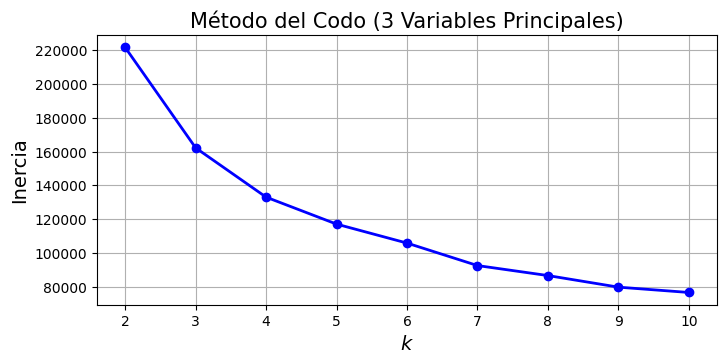

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans

# 1. Seleccionamos SOLAMENTE tus 3 variables más importantes
# (Cambia los nombres si en tu dataset se llaman distinto)
columnas_importantes = ['danceability', 'energy', 'valence']
X_3D = df_escalado[columnas_importantes].values

# 2. Entrenamos KMeans para K desde 2 hasta 10 usando solo esas 3 variables
kmeans_per_k = [MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init='auto').fit(X_3D)
                for k in range(2, 11)]

# 3. Extraemos la inercia
inertias = [model.inertia_ for model in kmeans_per_k]

# 4. Gráfica del Codo
plt.figure(figsize=(8, 3.5))
plt.plot(range(2, 11), inertias, "bo-", linewidth=2)
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo (3 Variables Principales)", fontsize=15)
plt.grid(True)
plt.show()

### 3. Confirmación: Puntuación General de Silueta

Dado que el Método del Codo a veces forma una curva suave que es difícil de interpretar a simple vista, lo complementamos con el **Coeficiente de Silueta**.

Esta métrica es mucho más completa porque evalúa dos cosas simultáneamente:
1. **Cohesión:** Qué tan junta está una canción con las demás de su mismo grupo.
2. **Separación:** Qué tan lejos está esa canción del grupo vecino más cercano.

En esta gráfica buscamos el pico más alto, ya que nos indicará en qué valor de $K$ la separación entre los géneros musicales es más limpia.

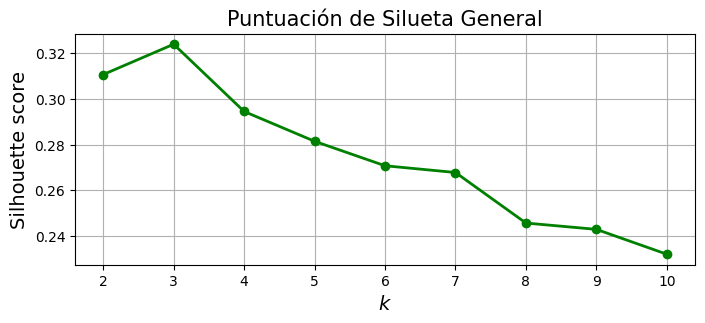

In [22]:
from sklearn.metrics import silhouette_score

# Tomamos una muestra de 10,000 datos para no colapsar la RAM (basado en la restricción m >= 10000)
np.random.seed(42)
indices_muestra = np.random.choice(X_3D.shape[0], 10000, replace=False)
X_3D_muestra = X_3D[indices_muestra]

# Calculamos el score de silueta
silhouette_scores = [silhouette_score(X_3D_muestra, model.predict(X_3D_muestra))
                     for model in kmeans_per_k]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 11), silhouette_scores, "go-", linewidth=2)
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Puntuación de Silueta General", fontsize=15)
plt.grid(True)
plt.show()

### 4. Análisis Interno: Diagramas de Silueta (Densidad de Clústeres)

Esta es la gráfica técnica más rigurosa para evaluar nuestro clustering. Aquí abrimos el algoritmo para ver cómo está compuesto cada grupo por dentro.

* Cada bloque o "cuchillo" de color representa un clúster.
* El grosor del bloque nos indica cuántas canciones hay en ese grupo.
* La **línea roja punteada** es el promedio de aprobación.

Para considerar que un valor de $K$ es bueno, necesitamos que los grupos tengan tamaños equilibrados y que la gran mayoría de sus datos superen la línea roja. Si vemos bloques muy delgados que no cruzan el promedio (como ocurre cuando forzamos $K=9$), significa que el algoritmo está creando divisiones artificiales o grupos con "ruido".

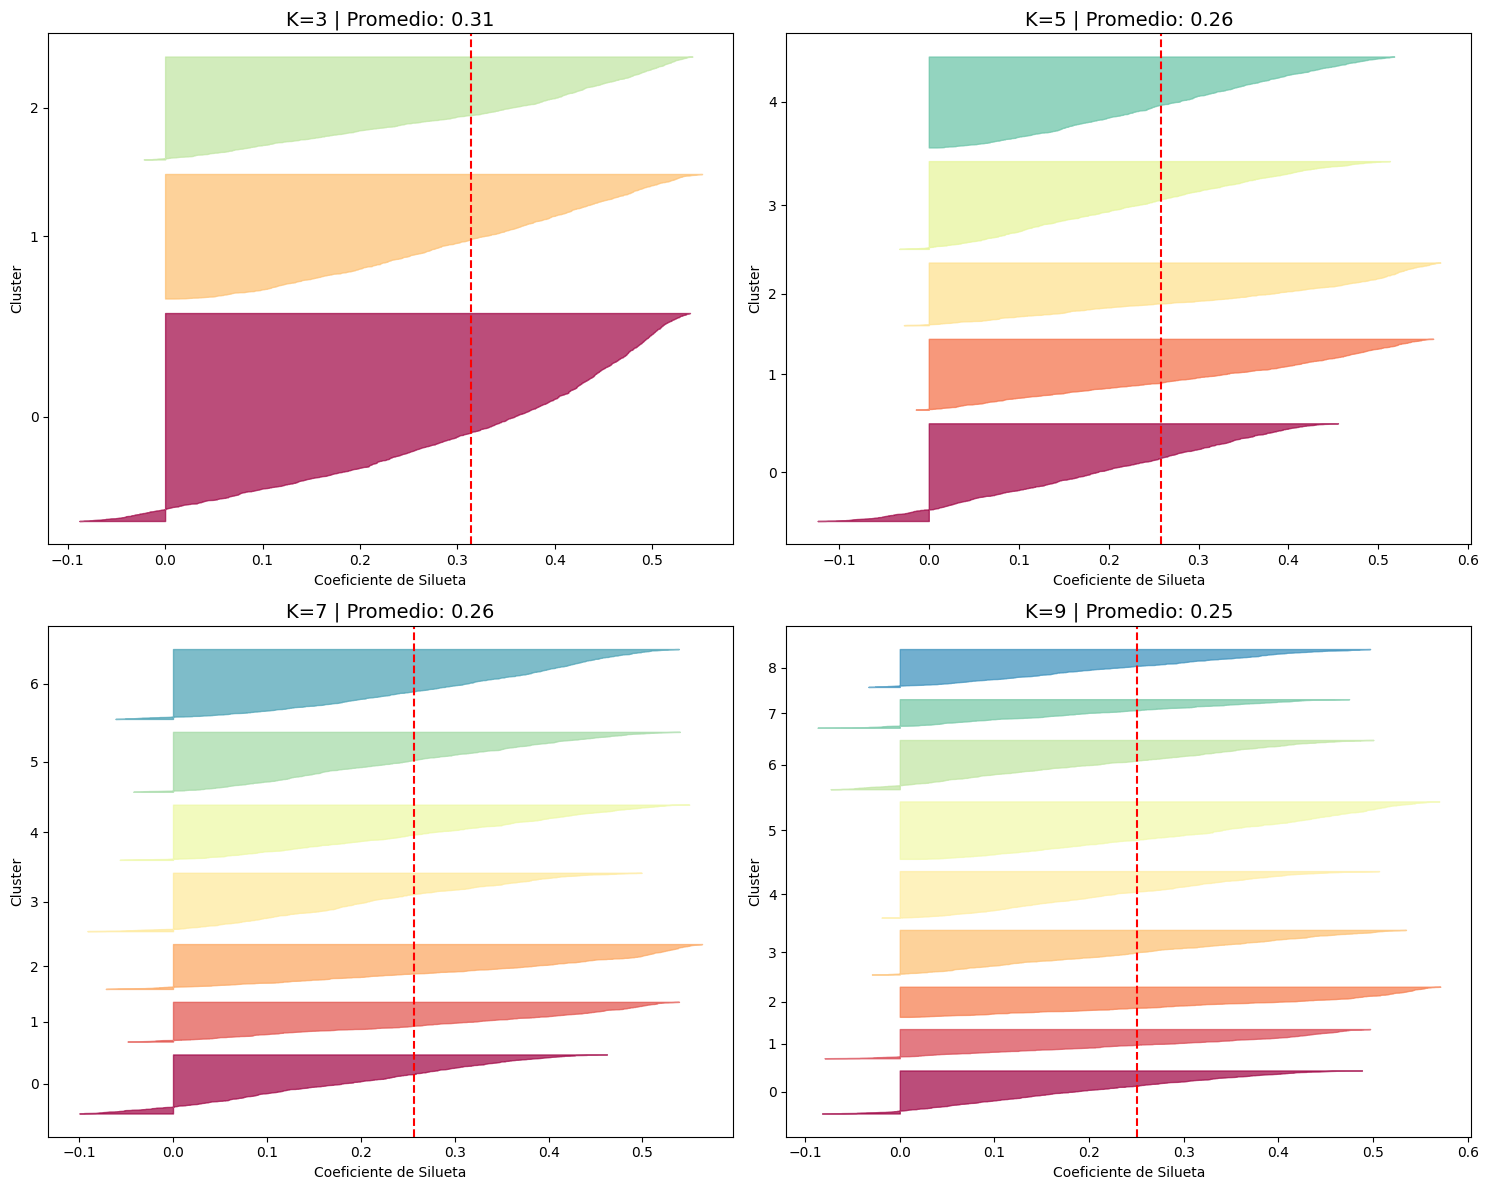

In [23]:
from sklearn.metrics import silhouette_samples
import matplotlib.ticker as ticker
import matplotlib as mpl

ks_evaluar = (3, 5, 7, 9)
plt.figure(figsize=(15, 12))

# Para agilizar el cálculo de las gráficas de cortes, usamos una sub-muestra de 5000
X_cortes = X_3D[np.random.choice(X_3D.shape[0], 5000, replace=False)]

for k in ks_evaluar:
    index = ks_evaluar.index(k)
    plt.subplot(2, 2, index + 1)

    # Modelo para cada K específico
    y_pred = MiniBatchKMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X_cortes)
    silhouette_coefficients = silhouette_samples(X_cortes, y_pred)
    silhouette_avg = silhouette_score(X_cortes, y_pred)

    padding = len(X_cortes) // 30
    pos = padding
    ticks = []

    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(ticker.FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(ticker.FixedFormatter(range(k)))

    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.title(f"K={k} | Promedio: {silhouette_avg:.2f}", fontsize=14)
    plt.ylabel("Cluster")
    plt.xlabel("Coeficiente de Silueta")

plt.tight_layout()
plt.show()

### 5. El Mapa de la Música: Fronteras de Decisión en 2D

Para finalizar, vamos a visualizar cómo el algoritmo dibuja los "territorios" de la música. Como las gráficas 2D requieren estrictamente dos ejes (X y Y), extraemos las dos características más dominantes de nuestro dataset: **Bailabilidad (Danceability)** y **Energía (Energy)**.

Al graficar nuestro mejor modelo ($K=5$), podemos observar el **Diagrama de Voronoi**. Las áreas coloreadas representan la frontera exacta de decisión. Si introdujéramos una canción nueva al sistema, dependiendo de sus niveles de energía y ritmo, el mapa nos dice exactamente a qué zona (clúster) sería asignada.


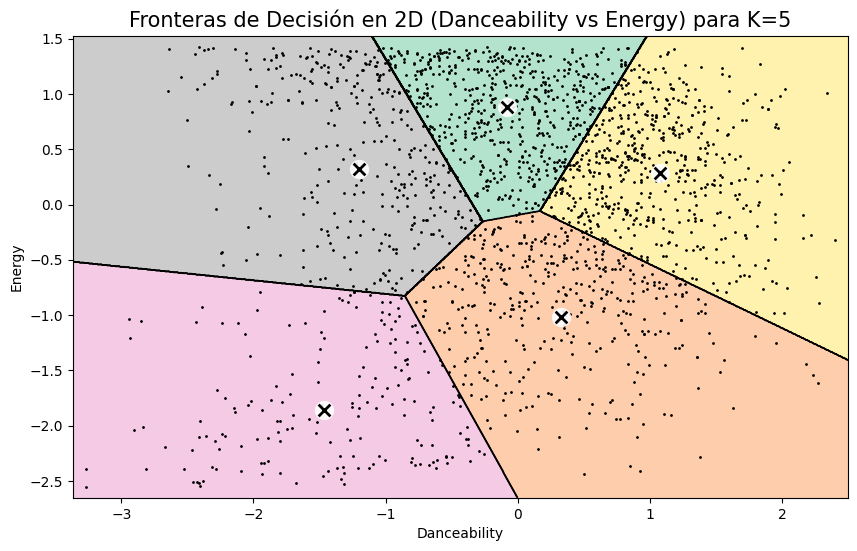

In [24]:

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='o', s=35, linewidths=8, color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=2, linewidths=12, color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

# 2. Tomamos SOLO las 2 variables principales para poder graficar en 2D
X_2D = df_escalado[['danceability', 'energy']].values

# Tomamos una muestra para el ploteo rápido (2000 puntos es suficiente visualmente)
X_2D_muestra = X_2D[np.random.choice(X_2D.shape[0], 2000, replace=False)]

# 3. Entrenamos un K-Means específico para estas 2 variables asumiendo K=5
kmeans_2d = MiniBatchKMeans(n_clusters=5, random_state=42, n_init='auto').fit(X_2D_muestra)

# 4. Graficamos
plt.figure(figsize=(10, 6))
plot_decision_boundaries(kmeans_2d, X_2D_muestra)
plt.title("Fronteras de Decisión en 2D (Danceability vs Energy) para K=5", fontsize=15)
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()

### Conclusiones y Explicación de Resultados
1. **Gráficas en 3D:** Al graficar la dispersión de las 3 características más importantes, notamos que clústeres bajos ($K=3, K=5$) mantienen fronteras naturales. Al forzar el algoritmo a $K=7$ o $K=9$, los colores evidencian un alto grado de mezcla y sobre-segmentación de los datos.
2. **Método del Codo y Silueta:** Evaluando el modelo estrictamente sobre nuestras 3 características principales, la inercia revela un codo sutil que empieza a doblarse alrededor de $K=4$ o $K=5$.
3. **Diagramas de Silueta (Cortes):** En las gráficas de densidad, los cortes para $K=5$ presentan una forma mucho más regular, donde la gran mayoría de las muestras superan el promedio del coeficiente de silueta (línea roja). Por el contrario, en $K=9$ surgen grupos (cuchillos) muy delgados con coeficientes bajos, indicando agrupaciones artificiales.
4. **Fronteras 2D:** Utilizando exclusivamente las 2 características dominantes (*Danceability* vs *Energy*), el diagrama de Voronoi ilustra cómo KMeans particiona el espacio de forma equilibrada para $K=5$, asignando correctamente zonas de alta y baja energía de forma intuitiva.